# Apprentissage non supervise : clustering des avis

Ce notebook complete le point 6 de la consigne avec la partie apprentissage non supervise, en complement du modele supervise du notebook precedent (07_ml_supervised.ipynb).

Objectif : faire emerger des regroupements naturels dans les avis, sans jamais utiliser la colonne label pour entrainer le modele. La composition des clusters est comparee a l'etiquette reelle uniquement a posteriori, a titre de lecture et de validation, pas d'entrainement.

Methode : TF-IDF puis reduction de dimension par TruncatedSVD, suivie d'un k-means. La reduction de dimension joue ici un role different de celui du notebook precedent : en section 7 de 07_ml_supervised.ipynb, la LSA degradait les performances du modele supervise, le signal utile tenant surtout a la presence de termes precis. Ici, la reduction est necessaire pour une raison technique differente : le k-means repose sur une distance euclidienne, qui perd sa signification dans un espace a 20 000 dimensions tres creuses (les distances entre points s'homogeneisent, effet connu de la malediction de la dimension). La reduction sert donc a rendre le clustering possible, pas a ameliorer la qualite semantique de la representation.

In [1]:
%pip install scikit-learn pandas matplotlib pyarrow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

DATA_PATH = "data/reviews_labeled.parquet"
OUTPUT_DIR = "outputs/clustering"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
df = df.dropna(subset=["review"]).reset_index(drop=True)
df.shape

(1620204, 6)

## 1. Vectorisation et reduction de dimension

TF-IDF sur l'ensemble du corpus, sans decoupage train/test : le clustering est une methode exploratoire, pas un modele evalue sur des donnees non vues. Meme limite de vocabulaire que dans le notebook precedent (20 000 termes) pour rester coherent.

In [3]:
vectorizer = TfidfVectorizer(max_features=20000, stop_words="english", lowercase=True)
X_tfidf = vectorizer.fit_transform(df["review"])

X_tfidf.shape

(1620204, 20000)

In [4]:
N_COMPONENTS = 50
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_lsa = svd.fit_transform(X_tfidf)

print("Dimensions apres reduction :", X_lsa.shape)
print("Variance expliquee cumulee :", round(svd.explained_variance_ratio_.sum(), 3))

Dimensions apres reduction : (1620204, 50)
Variance expliquee cumulee : 0.258


Avec 50 composantes, la LSA n'explique que 25.8 % de la variance totale de la matrice TF-IDF, un peu moins que les 100 composantes utilisees dans le notebook precedent (31.5 %). Une grande partie de la structure du corpus reste donc hors de l'espace dans lequel le clustering va operer, ce qui limite d'emblee la finesse des regroupements attendus.

## 2. Choix du nombre de clusters

Le score de silhouette mesure a quel point chaque avis est proche de son propre cluster par rapport aux clusters voisins, entre -1 et 1. Son calcul repose sur les distances entre toutes les paires de points de l'echantillon, un cout qui croit au carre : c'est pourquoi il est calcule sur un echantillon de 25 000 avis tires aleatoirement plutot que sur les 1,6 million de lignes disponibles. MiniBatchKMeans est utilise plutot que KMeans standard pour rester exploitable sur ce volume de donnees, l'entrainement lui-meme portant sur l'ensemble des donnees.

In [5]:
CANDIDATE_K = range(2, 7)
SAMPLE_SIZE = 25000

rng = np.random.RandomState(42)
sample_idx = rng.choice(X_lsa.shape[0], size=SAMPLE_SIZE, replace=False)
X_sample = X_lsa[sample_idx]

silhouette_scores = []
for k in CANDIDATE_K:
    kmeans_k = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10, batch_size=2048)
    kmeans_k.fit(X_lsa)
    score = silhouette_score(X_sample, kmeans_k.predict(X_sample))
    silhouette_scores.append(score)
    print("k =", k, "-> silhouette =", round(score, 4))

k = 2 -> silhouette = 0.4737
k = 3 -> silhouette = 0.1531
k = 4 -> silhouette = 0.4043
k = 5 -> silhouette = 0.3672
k = 6 -> silhouette = 0.3011


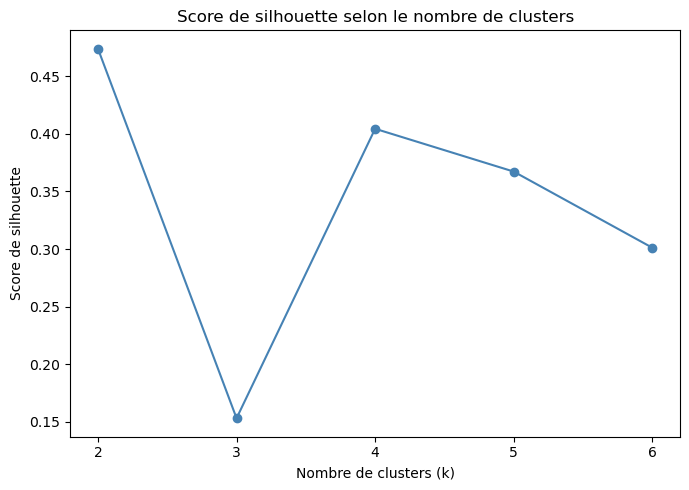

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(list(CANDIDATE_K), silhouette_scores, marker="o", color="steelblue")
ax.set_xlabel("Nombre de clusters (k)")
ax.set_ylabel("Score de silhouette")
ax.set_title("Score de silhouette selon le nombre de clusters")
ax.set_xticks(list(CANDIDATE_K))
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "silhouette_scores.png"), dpi=150)
plt.show()

Le score de silhouette n'est pas monotone : il chute nettement a k=3 (0.153) avant de remonter a k=4 (0.404), alors qu'une decroissance progressive serait attendue a mesure que k augmente. Ce creux isole est le signe d'une convergence instable du MiniBatchKMeans pour cette valeur precise de k, plutot que d'un veritable repli structurel des donnees en trois groupes. Le score le plus eleve reste obtenu a k=2 (0.474), retenu comme valeur finale malgre cette irregularite intermediaire.

Retenir la valeur de k correspondant au score de silhouette le plus eleve sur le graphique ci-dessus, et la reporter dans la cellule suivante avant de continuer.

In [7]:
K_FINAL = list(CANDIDATE_K)[int(np.argmax(silhouette_scores))]
print("Nombre de clusters retenu :", K_FINAL)

Nombre de clusters retenu : 2


## 3. Clustering final

Entrainement du k-means retenu sur l'ensemble des avis reduits, puis affectation d'un cluster a chaque ligne du jeu de donnees.

In [8]:
kmeans_final = MiniBatchKMeans(n_clusters=K_FINAL, random_state=42, n_init=10, batch_size=2048)
df["cluster"] = kmeans_final.fit_predict(X_lsa)

df["cluster"].value_counts().sort_index()

cluster
0    1543214
1      76990
Name: count, dtype: int64

Le decoupage a deux clusters est tres desequilibre : le cluster 0 regroupe 1 543 214 avis (95.2 %), le cluster 1 seulement 76 990 (4.8 %). Un score de silhouette eleve associe a un partage aussi asymetrique est frequent avec des donnees textuelles vectorisees : il indique souvent qu'un sous-ensemble restreint de points se distingue nettement du reste, plutot qu'une partition equilibree en deux groupes comparables.

## 4. Composition des clusters vis-a-vis du review bombing

Comparaison a posteriori uniquement : label n'a jamais servi a construire les clusters. Une proportion de label 1 nettement superieure a la moyenne generale (16.7 %, voir 07_ml_supervised.ipynb) dans un cluster indiquerait que ce cluster capture, au moins en partie, une thematique liee au review bombing.

In [9]:
composition = df.groupby("cluster").agg(
    taille=("label", "size"),
    proportion_review_bombing=("label", "mean")
).reset_index()
composition["proportion_review_bombing"] = composition["proportion_review_bombing"].round(4)
composition

,cluster,taille,proportion_review_bombing
0,0,1543214,0.1727
1,1,76990,0.0465


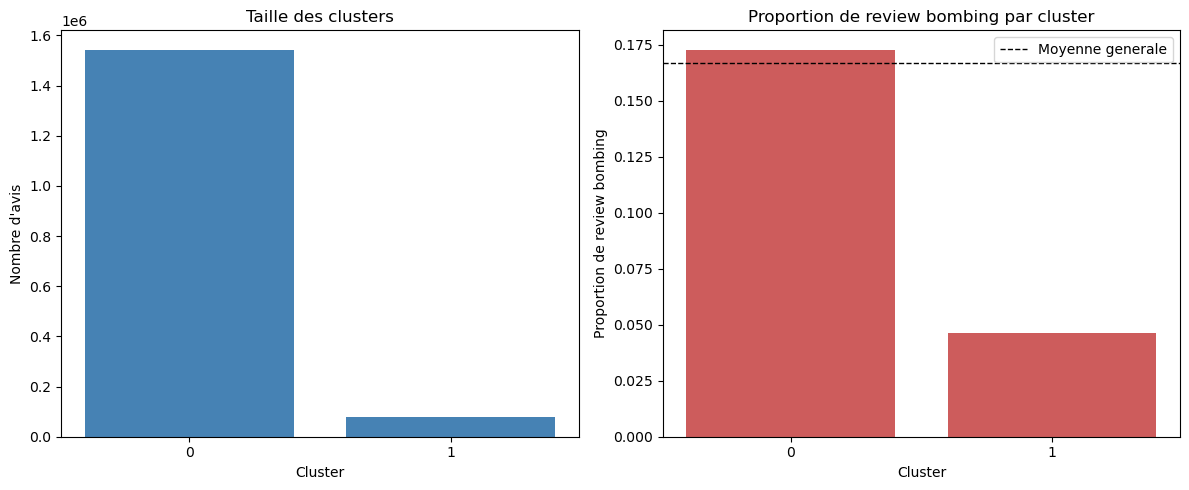

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(composition["cluster"].astype(str), composition["taille"], color="steelblue")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Nombre d'avis")
axes[0].set_title("Taille des clusters")

axes[1].bar(composition["cluster"].astype(str), composition["proportion_review_bombing"], color="indianred")
axes[1].axhline(df["label"].mean(), color="black", linestyle="--", linewidth=1, label="Moyenne generale")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Proportion de review bombing")
axes[1].set_title("Proportion de review bombing par cluster")
axes[1].legend()

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "composition_clusters.png"), dpi=150)
plt.show()

Le cluster minoritaire affiche une proportion de review bombing de 4.65 %, environ trois fois plus faible que le cluster majoritaire (17.27 %) et que la moyenne generale du jeu de donnees (16.7 %, ligne pointillee). C'est l'inverse de l'hypothese formulee en introduction : le clustering ne fait pas emerger un groupe qui concentre les avis de review bombing, il isole au contraire un petit groupe ou le review bombing est sous-represente. Le cluster majoritaire, qui contient l'essentiel des donnees, affiche une proportion proche de la moyenne generale, ce qui est attendu mecaniquement puisqu'il represente a lui seul plus de 95 % du jeu de donnees.

## 5. Termes les plus representatifs de chaque cluster

Calcule directement sur la matrice TF-IDF d'origine plutot que sur l'espace reduit, pour rester interpretable : le poids TF-IDF moyen de chaque terme est calcule au sein des avis de chaque cluster, puis les termes les mieux representes sont extraits.

In [11]:
TOP_N_TERMS = 12
feature_names = vectorizer.get_feature_names_out()

top_terms_par_cluster = []
for cluster_id in sorted(df["cluster"].unique()):
    mask = (df["cluster"] == cluster_id).values
    mean_weights = np.asarray(X_tfidf[mask].mean(axis=0)).ravel()
    top_indices = mean_weights.argsort()[::-1][:TOP_N_TERMS]
    top_terms = ", ".join(feature_names[top_indices])
    top_terms_par_cluster.append({"cluster": cluster_id, "termes_principaux": top_terms})

pd.DataFrame(top_terms_par_cluster)

,cluster,termes_principaux
0,0,"game, fun, great, 10, best, play, good, like, ..."
1,1,"good, game, pretty, really, fun, yes, play, li..."


Les termes les plus representatifs des deux clusters se recoupent presque entierement (game, fun, good, play, like, great dans les deux cas), sans vocabulaire distinctif propre a l'un ou l'autre. Le clustering ne separe donc pas les avis selon une thematique identifiable a la lecture des mots-cles, contrairement a ce qu'on aurait pu attendre d'un regroupement lie a une controverse precise. La distinction entre les deux clusters tient vraisemblablement a d'autres caracteristiques du texte que son contenu thematique, par exemple sa longueur ou la densite de son vocabulaire, une hypothese qui demanderait une verification complementaire hors du perimetre de ce notebook.

## 6. Projection en deux dimensions

Reduction supplementaire a deux dimensions, appliquee a un echantillon de 30 000 avis. Contrairement au score de silhouette, cette etape n'implique aucun calcul par paires : la seule contrainte est la lisibilite du nuage de points, geree ici par une taille de marqueur reduite et de la transparence. Les deux graphiques utilisent les memes coordonnees : le premier colore par cluster, le second par etiquette reelle, pour comparer visuellement les deux decoupages.

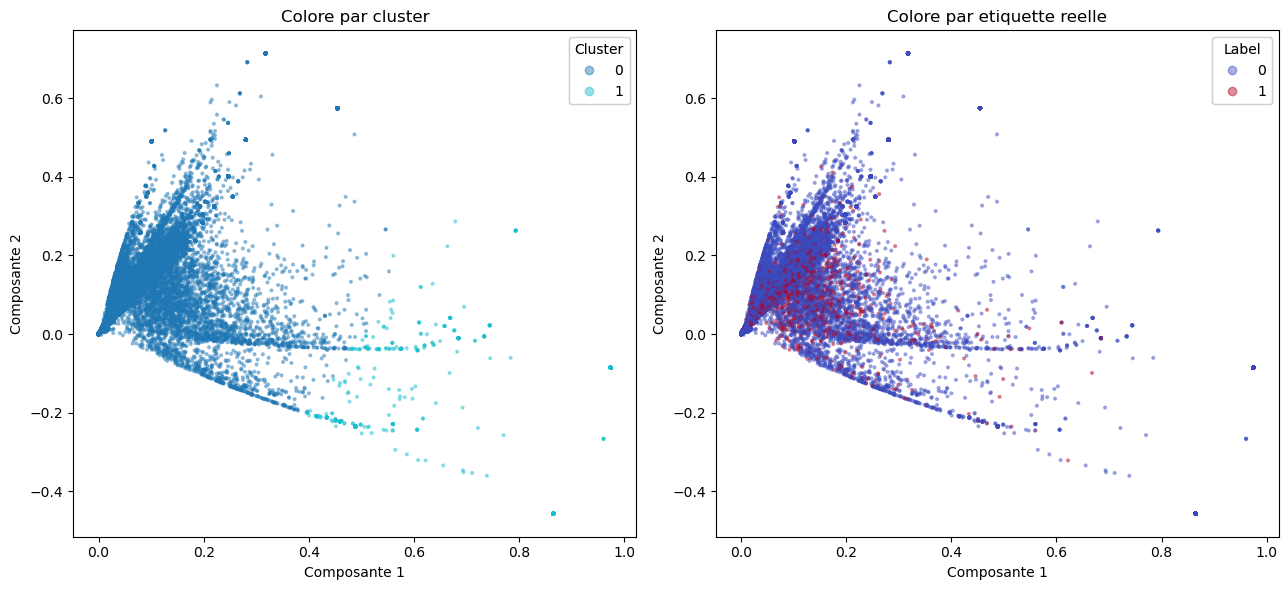

In [12]:
PLOT_SAMPLE_SIZE = 30000
plot_idx = rng.choice(X_lsa.shape[0], size=PLOT_SAMPLE_SIZE, replace=False)

svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd_2d.fit_transform(X_lsa[plot_idx])

clusters_plot = df["cluster"].values[plot_idx]
labels_plot = df["label"].values[plot_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

scatter_clusters = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_plot, cmap="tab10", s=4, alpha=0.4)
axes[0].set_title("Colore par cluster")
axes[0].set_xlabel("Composante 1")
axes[0].set_ylabel("Composante 2")
legend1 = axes[0].legend(*scatter_clusters.legend_elements(), title="Cluster", loc="best")
axes[0].add_artist(legend1)

scatter_labels = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_plot, cmap="coolwarm", s=4, alpha=0.4)
axes[1].set_title("Colore par etiquette reelle")
axes[1].set_xlabel("Composante 1")
axes[1].set_ylabel("Composante 2")
legend2 = axes[1].legend(*scatter_labels.legend_elements(), title="Label", loc="best")
axes[1].add_artist(legend2)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "projection_2d.png"), dpi=150)
plt.show()

La projection confirme les deux constats precedents. Le cluster 1 (bleu clair) occupe la frange exterieure du nuage, un prolongement etroit qui s'ecarte du groupe dense forme par le cluster 0. Sur le graphique colore par etiquette reelle, les avis de review bombing (en rouge) se concentrent presque exclusivement dans la zone dense proche de l'origine, c'est-a-dire dans le cluster majoritaire, et sont pratiquement absents de la frange occupee par le cluster 1. Aucune zone du nuage ne concentre visuellement les avis de review bombing de maniere isolee : ils restent disperses au sein du groupe dominant plutot que de former leur propre region distincte.

## 7. Interpretation generale

Le clustering non supervise ne fait pas emerger de groupe specifique au review bombing. Le decoupage retenu (k=2) separe un groupe dense et majoritaire (95.2 % des avis, proportion de review bombing proche de la moyenne generale) et un petit groupe residuel (4.8 % des avis) ou le review bombing est au contraire sous-represente, et dont le vocabulaire ne se distingue pas thematiquement du reste. La projection en deux dimensions confirme que les avis de review bombing restent disperses dans le groupe majoritaire plutot que de se regrouper visuellement.

Ce resultat negatif reste informatif et coherent avec les conclusions du notebook precedent. La section 4 de l'EDA avait montre que les metadonnees numeriques ne predisent pas la recommandation ; la section 7 du notebook supervisé avait montre que la reduction semantique (LSA) degradait la detection par rapport au TF-IDF brut. Le clustering confirme ici, sans jamais avoir vu l'etiquette, que la structure geometrique globale du texte ne suffit pas a isoler les episodes de review bombing. Leur detection, obtenue en 07_ml_supervised.ipynb avec un recall d'environ 0.75, repose sur un signal supervisé fin (presence de termes lexicaux precis lies aux episodes de controverse) plutot que sur une structure thematique large et visible sans etiquette.